In [1]:
import scanpy as  sc
import anndata as ad
import loompy
import scvelo as scv
import scanpy as sc
import os
import pickle
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.collections as mc
print('import successful')

import successful


In [2]:
dataset = 'S-MG'

In [ ]:
adata=sc.read_h5ad(f"../../S-MG/1.subset/{dataset}_cleaned.h5ad")
adata

AnnData object with n_obs × n_vars = 22855 × 12088
    obs: 'sample', 'n_genes_by_counts', 'total_counts', 'doublet_score', 'predicted_doublet', 'gland', 'stage_old', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'total_counts_MT', 'pct_counts_MT', 'log1p_total_counts_MT', 'total_counts_RIBO', 'pct_counts_RIBO', 'log1p_total_counts_RIBO', 'leiden', 'anno', 'stage_new', 'species', 'celltype', 'stage', 'cellid', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'newcelltype', 'subtype'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'dendrogram_leiden', 'gland_colors', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'newcelltype_colors', 'pca', 'rank_genes_groups', 'sample_colors', 'stage_colors', 'subtype_colors', 'umap'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap'
    varm: 'PCs'
    layers: 'ambiguous', 'counts', 'matrix', 'normalized', 'spliced', 'unspliced'


<Axes: title={'center': 'leiden'}, xlabel='UMAP1', ylabel='UMAP2'>

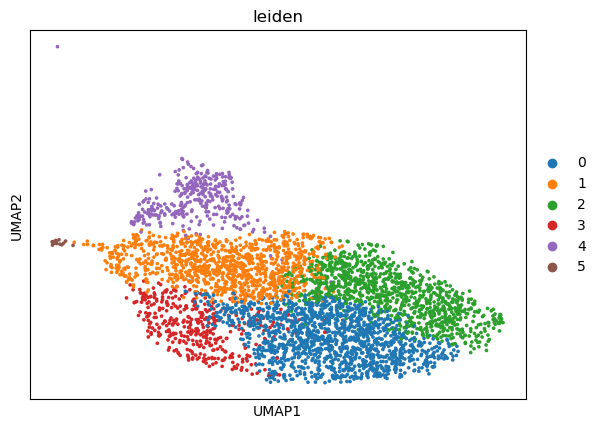

In [4]:
adata_sub = adata[adata.obs['newcelltype'].isin(['LumHR'])].copy()
sc.tl.leiden(adata_sub,resolution=0.3)
sc.pl.umap(adata_sub,color='leiden',show=False)

In [5]:
fig = plt.gcf()
for ax in fig.axes:
    for coll in ax.collections:
        if isinstance(coll, mc.PathCollection):   # 只栅格化散点
            coll.set_rasterized(True)
# 3) 保存为 PDF：dpi 只影响被 rasterize 的那部分（也就是点）
fig.savefig(f'{dataset}-umap-lumhr-c4.pdf', bbox_inches="tight", dpi=300)
plt.close(fig)

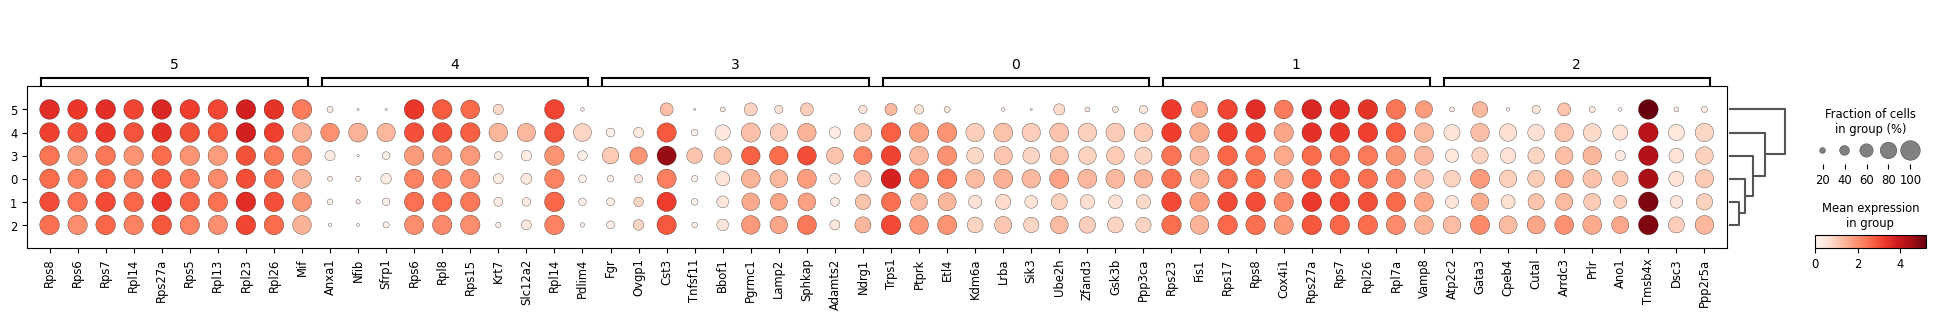

In [6]:
sc.tl.rank_genes_groups(adata_sub,groupby='leiden',key_added='subHR')
sc.tl.dendrogram(adata_sub, groupby='leiden')
sc.pl.rank_genes_groups_dotplot(adata_sub,groupby='leiden',n_genes=10,save=f'{dataset}-LumHR_dotplot_leiden.pdf',min_logfoldchange=0.25,key='subHR')

In [7]:
df=sc.get.rank_genes_groups_df(adata_sub,key='subHR',group=None,log2fc_min=0.25,pval_cutoff=0.01)
df.to_csv('S-MG-LumHR.csv',index=False)
df1=df.groupby('group').head(50)
glist=df1.loc[df1['group']=='4','names'].tolist()
exclude_prefix = ('Rpl', 'Rps')
filtered_list = [gene for gene in glist if not gene.startswith(exclude_prefix)]
filtered_list

['Anxa1',
 'Nfib',
 'Sfrp1',
 'Krt7',
 'Slc12a2',
 'Pdlim4',
 'Igfbp5',
 'Rack1',
 'Vim',
 'Clu',
 'Btg1',
 'Tagln2',
 'Sh3bp4',
 'Krt80',
 'Dpysl2',
 'Eef1g',
 'Sfrp5',
 'Grhl1',
 'Slc11a2',
 'Magi3',
 'S100a10',
 'Myh9',
 'Crip2',
 'Tm4sf1',
 'Errfi1',
 'Barx2',
 'Sh3bgrl3',
 'Clic4',
 'Anpep',
 'Fxyd3',
 'Slc40a1']

In [8]:
sc.tl.score_genes(adata,gene_list=filtered_list,score_name='c4')

MemoryError: In RendererAgg: Out of memory

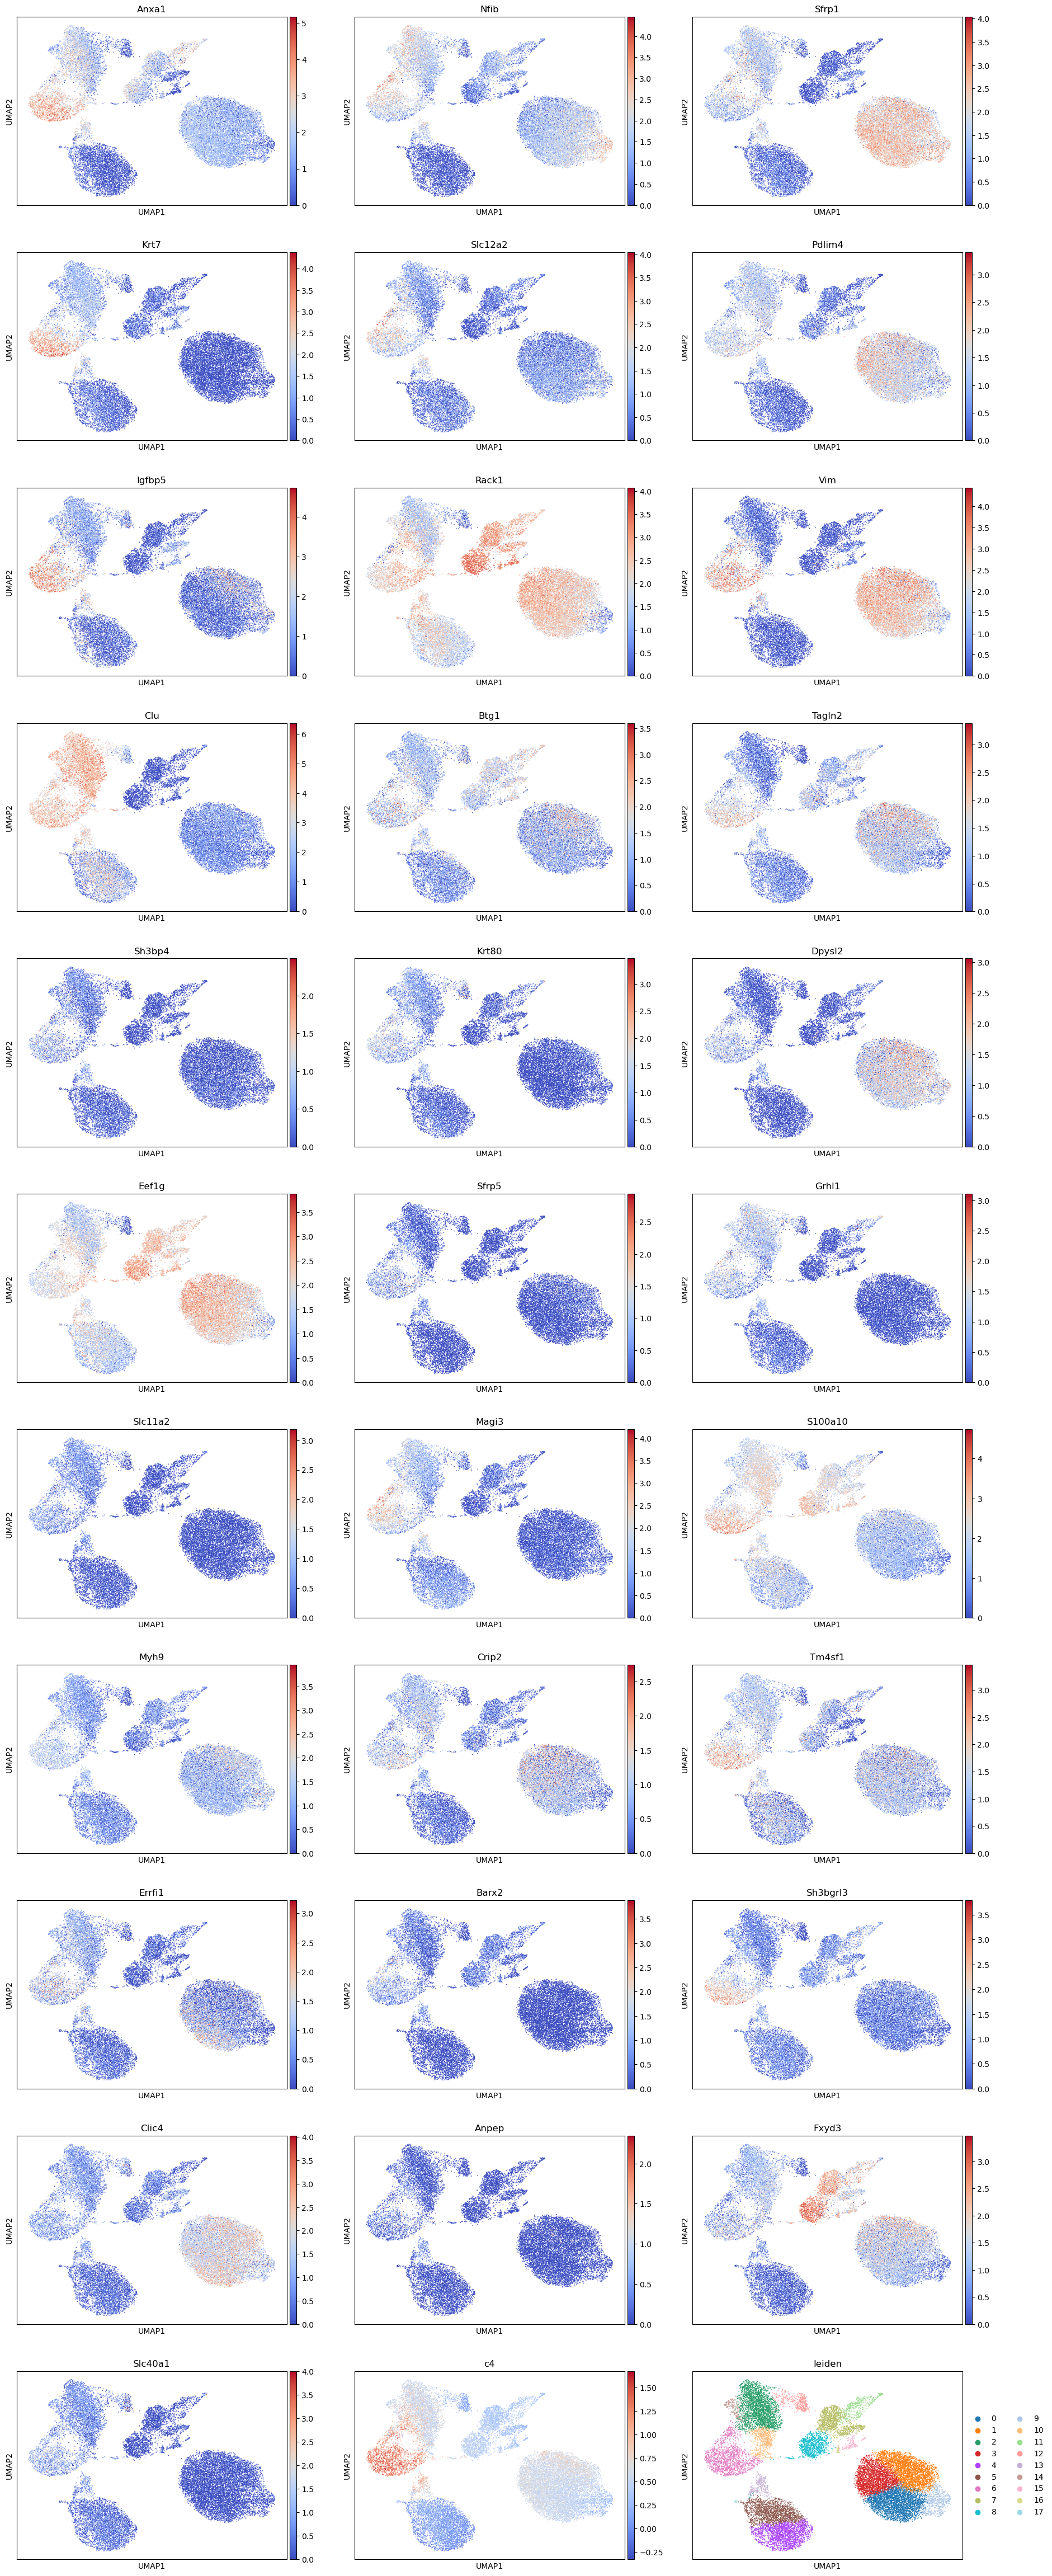

In [9]:
sc.pl.umap(adata,color=[*filtered_list,'c4','leiden'],ncols=3,show=False,cmap="coolwarm")
fig = plt.gcf()
for ax in fig.axes:
    for coll in ax.collections:
        if isinstance(coll, mc.PathCollection):   # 只栅格化散点
            coll.set_rasterized(True)
# 3) 保存为 PDF：dpi 只影响被 rasterize 的那部分（也就是点）
fig.savefig(f'{dataset}-umap-lumhr-c4.pdf', bbox_inches="tight", dpi=300)
plt.close(fig)

In [ ]:
dataset = 'S-AG'

In [ ]:
adata2=sc.read_h5ad(f"../../S-AG/1.subset/{dataset}_cleaned.h5ad")

In [ ]:
sc.tl.score_genes(adata2,gene_list=filtered_list,score_name='c4')

In [ ]:
sc.pl.umap(adata2,color=[*filtered_list,'c4','leiden'],ncols=3,show=False,cmap="coolwarm")
fig = plt.gcf()
for ax in fig.axes:
    for coll in ax.collections:
        if isinstance(coll, mc.PathCollection):   # 只栅格化散点
            coll.set_rasterized(True)
# 3) 保存为 PDF：dpi 只影响被 rasterize 的那部分（也就是点）
fig.savefig(f'{dataset}-umap-lumhr-c4', bbox_inches="tight", dpi=300)
plt.close(fig)